# Networking

0. [Motivation](#Motivation)
1. [socket](#socket)
2. [TCP](#TCP)
3. [UDP](#UDP)
4. [HTTP](#HTTP)
5. [web-servers](#web-servers)

## Motivation

__Goal__

Получить знания об особенносятх сетевого взаимодействия, изучить нюансы общения со сторонними сервисами и создания собственных

__Homework__

HTTP Server

## Networking

#### socket

In [ ]:
import socket

class Connection(object):
    '''\
    Represents connection to the Tarantool server.

    This class is responsible for connection and network exchange with the server.
    Also this class provides low-level interface to data manipulation (insert/delete/update/select).
    '''

    def __init__(self, host, port,
                 socket_timeout=SOCKET_TIMEOUT,
                 reconnect_max_attempts=RECONNECT_MAX_ATTEMPTS,
                 reconnect_delay=RECONNECT_DELAY,
                 connect_now=True,
                 schema=None):
        '''\
        Initialize a connection to the server.

        :param str host: Server hostname or IP-address
        :param int port: Server port
        :param bool connect_now: if True (default) than __init__() actually creates network connection.
                             if False than you have to call connect() manualy.
        :param schema: Data schema (see Developer guide and :class:`~tarantool.schema.Schema`)
        :type schema: :class:`~tarantool.schema.Schema` or dict
        '''
        self.host = host
        self.port = port
        self.socket_timeout = socket_timeout
        self.reconnect_delay = reconnect_delay
        self.reconnect_max_attempts = reconnect_max_attempts
        if isinstance(schema, Schema):
            self.schema = schema
        else:
            self.schema = Schema(schema)
        self._socket = None
        if connect_now:
            self.connect()


    def close(self):
        '''\
        Close connection to the server
        '''
        self._socket.close()
        self._socket = None


    def connect(self):
        '''\
        Create connection to the host and port specified in __init__().
        Usually there is no need to call this method directly,
        since it is called when you create an `Connection` instance.

        :raise: `NetworkError`
        '''

        try:
            # If old socket already exists - close it and re-create
            if self._socket:
                self._socket.close()
            self._socket = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
            self._socket.setsockopt(socket.SOL_TCP, socket.TCP_NODELAY, 1)
            #self._socket.setsockopt(socket.SOL_TCP, socket.SO_REUSEADDR, 1)
            #self._socket.setsockopt(socket.SOL_TCP, socket.SO_REUSEPORT, 1)
            self._socket.connect((self.host, self.port))
            # It is important to set socket timeout *after* connection.
            # Otherwise the timeout exception will rised, even if the server does not listen
            self._socket.settimeout(self.socket_timeout)
        except socket.error as e:
            raise NetworkError(e)


    def _read_response(self):
        '''
        Read response from the transport (socket)

        :return: tuple of the form (header, body)
        :rtype: tuple of two byte arrays
        '''

        buf = ''
        l = 12

        while True:
            r = self._socket.recv(l - len(buf))
            if not r:
                err = socket.error("Connection reset by peer")
                err.errno = errno.ECONNRESET
                raise err
            buf += r
            if len(buf) < l:
                continue

            l = 12 + struct_L.unpack(buf[4:8])[0] # struct.unpack("<Q", buf[4:8])[0]

            if len(buf) < l:
                continue

            return buf[0:12], buf[12:]

        
    def _send_request_wo_reconnect(self, request, space_name = None, field_defs = None, default_type = None):
        '''\
        :rtype: `Response` instance

        :raise: NetworkError
        '''
        assert isinstance(request, Request)

        # Repeat request in a loop if the server returns completion_status == 1 (try again)
        for attempt in xrange(self.RETRY_MAX_ATTEMPTS):    # pylint: disable=W0612
            try:
                self._socket.sendall(bytes(request))
                header, body = self._read_response()
                response = Response(self, header, body, space_name, field_defs, default_type)
            except socket.error as e:
                raise NetworkError(e)

            if response.completion_status != 1:
                return response
            warn(response.return_message, RetryWarning)

        # Raise an error if the maximum number of attempts have been made
        raise DatabaseError(response.return_code, response.return_message)

Socket is not file object but `makefile` fixes it
* It's easy to write programs that mysteriously "freeze up" or don't operate quite like you would expect

In [ ]:
class HTTPResponse:

    # strict: If true, raise BadStatusLine if the status line can't be
    # parsed as a valid HTTP/1.0 or 1.1 status line.  By default it is
    # false because it prevents clients from talking to HTTP/0.9
    # servers.  Note that a response with a sufficiently corrupted
    # status line will look like an HTTP/0.9 response.

    # See RFC 2616 sec 19.6 and RFC 1945 sec 6 for details.

    def __init__(self, sock, debuglevel=0, strict=0, method=None, buffering=False):
        if buffering:
            # The caller won't be using any sock.recv() calls, so buffering
            # is fine and recommended for performance.
            self.fp = sock.makefile('rb')
        else:
            # The buffer size is specified as zero, because the headers of
            # the response are read with readline().  If the reads were
            # buffered the readline() calls could consume some of the
            # response, which make be read via a recv() on the underlying
            # socket.
            self.fp = sock.makefile('rb', 0)
        self.debuglevel = debuglevel
        self.strict = strict
        self._method = method

        self.msg = None

        # from the Status-Line of the response
        self.version = _UNKNOWN # HTTP-Version
        self.status = _UNKNOWN  # Status-Code
        self.reason = _UNKNOWN  # Reason-Phrase

        self.chunked = _UNKNOWN         # is "chunked" being used?
        self.chunk_left = _UNKNOWN      # bytes left to read in current chunk
        self.length = _UNKNOWN          # number of bytes left in response
        self.will_close = _UNKNOWN      # conn will close at end of response

    def _read_status(self):
        # Initialize with Simple-Response defaults
        line = self.fp.readline(_MAXLINE + 1)
        if len(line) > _MAXLINE:
            raise LineTooLong("header line")
        if self.debuglevel > 0:
            print "reply:", repr(line)
        if not line:
            # Presumably, the server closed the connection before
            # sending a valid response.
            raise BadStatusLine(line)
        try:
            [version, status, reason] = line.split(None, 2)
        except ValueError:
            try:
                [version, status] = line.split(None, 1)
                reason = ""
            except ValueError:
                # empty version will cause next test to fail and status
                # will be treated as 0.9 response.
                version = ""
        if not version.startswith('HTTP/'):
            if self.strict:
                self.close()
                raise BadStatusLine(line)
            else:
                # assume it's a Simple-Response from an 0.9 server
                self.fp = LineAndFileWrapper(line, self.fp)
                return "HTTP/0.9", 200, ""

        # The status code is a three-digit number
        try:
            status = int(status)
            if status < 100 or status > 999:
                raise BadStatusLine(line)
        except ValueError:
            raise BadStatusLine(line)
        return version, status, reason

Be aware that reading/writing to a socket may involve partial data transfer
* send() returns actual bytes sent
    * you want to use s.sendall(data) - blocks until all is sent
* recv() length is only a maximum limit
    * will return empty string when connections has been closed
* for TCP, the data stream is continuous - no concept of records, etc.

In [ ]:
>>> len(data)
1000000
>>> s.send(data)
37722
>>>
>>> data = s.recv(10000)
>>> len(data)
6420

In [ ]:
# Client
...
s.send(data)
s.send(moredata)
...
# Server
...
data = s.recv(maxsize) # This recv() may return data
                       # from both of the sends
                       # combined or less data than
                       # even the first send

#### TCP

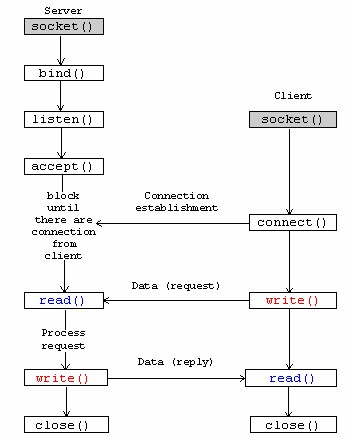

In [ ]:
from socket import *
s = socket(AF_INET, SOCK_STREAM)
s.bind(("", 9000))
s.listen(5)
while True:
    c, a = s.accept()
    print "Received connection from", a
    c.sendall("Hello %s\n" % a[0])
    c.close()

In [121]:
def _eintr_retry(func, *args):
    """restart a system call interrupted by EINTR"""
    while True:
        try:
            return func(*args)
        except (OSError, select.error) as e:
            if e.args[0] != errno.EINTR:
                raise

                
class BaseServer:
    timeout = None
    def __init__(self, server_address, RequestHandlerClass):
        """Constructor.  May be extended, do not override."""
        self.server_address = server_address
        self.RequestHandlerClass = RequestHandlerClass
        self.__is_shut_down = threading.Event()
        self.__shutdown_request = False

    def serve_forever(self, poll_interval=0.5):
        """Handle one request at a time until shutdown.
        Polls for shutdown every poll_interval seconds. Ignores
        self.timeout. If you need to do periodic tasks, do them in
        another thread.
        """
        self.__is_shut_down.clear()
        try:
            while not self.__shutdown_request:
                # XXX: Consider using another file descriptor or
                # connecting to the socket to wake this up instead of
                # polling. Polling reduces our responsiveness to a
#                 shutdown request and wastes cpu at all other times.
#                 r, w, e = select.select([self], [], [], poll_interval)
                r, w, e = _eintr_retry(select.select, [self], [], [],
                                       poll_interval)
                if self in r:
                    self._handle_request_noblock()
        finally:
            self.__shutdown_request = False
            self.__is_shut_down.set()

    def shutdown(self):
        """Stops the serve_forever loop.
        Blocks until the loop has finished. This must be called while
        serve_forever() is running in another thread, or it will
        deadlock.
        """
        self.__shutdown_request = True
        self.__is_shut_down.wait()

    def _handle_request_noblock(self):
        """Handle one request, without blocking.
        I assume that select.select has returned that the socket is
        readable before this function was called, so there should be
        no risk of blocking in get_request().
        """
        try:
            request, client_address = self.get_request()
        except socket.error:
            return
        if self.verify_request(request, client_address):
            try:
                self.process_request(request, client_address)
            except:
                self.handle_error(request, client_address)
                self.shutdown_request(request)
        else:
            self.shutdown_request(request)

    def process_request(self, request, client_address):
        """Call finish_request.
        Overridden by ForkingMixIn and ThreadingMixIn.
        """
        self.finish_request(request, client_address)
        self.shutdown_request(request)

    def finish_request(self, request, client_address):
        """Finish one request by instantiating RequestHandlerClass."""
        self.RequestHandlerClass(request, client_address, self)

In [ ]:
class TCPServer(BaseServer):
    address_family = socket.AF_INET
    socket_type = socket.SOCK_STREAM
    request_queue_size = 5
    allow_reuse_address = False

    def __init__(self, server_address, RequestHandlerClass, bind_and_activate=True):
        """Constructor.  May be extended, do not override."""
        BaseServer.__init__(self, server_address, RequestHandlerClass)
        self.socket = socket.socket(self.address_family,
                                    self.socket_type)
        if bind_and_activate:
            try:
                self.server_bind()
                self.server_activate()
            except:
                self.server_close()
                raise

    def server_bind(self):
        """Called by constructor to bind the socket.
        May be overridden.
        """
        if self.allow_reuse_address:
            self.socket.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
        self.socket.bind(self.server_address)
        self.server_address = self.socket.getsockname()

    def server_activate(self):
        """Called by constructor to activate the server.
        May be overridden.
        """
        self.socket.listen(self.request_queue_size)

    def server_close(self):
        """Called to clean-up the server.
        May be overridden.
        """
        self.socket.close()

    def fileno(self):
        """Return socket file number.
        Interface required by select().
        """
        return self.socket.fileno()

    def get_request(self):
        """Get the request and client address from the socket.
        May be overridden.
        """
        return self.socket.accept()

    def shutdown_request(self, request):
        """Called to shutdown and close an individual request."""
        try:
            #explicitly shutdown.  socket.close() merely releases
            #the socket and waits for GC to perform the actual close.
            request.shutdown(socket.SHUT_WR)
        except socket.error:
            pass #some platforms may raise ENOTCONN here
        self.close_request(request)

    def close_request(self, request):
        """Called to clean up an individual request."""
        request.close()


#### UDP

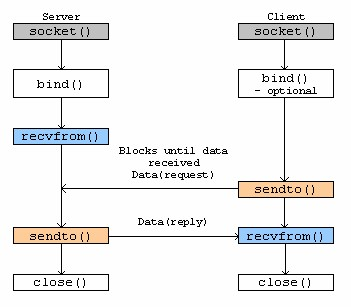

In [ ]:
# Simple server
from socket import *
s = socket(AF_INET, SOCK_DGRAM)
s.bind(("", 10000))
while True:
    data, addr = s.recvfrom(maxsize)
    resp = "Get off my lawn!"
    s.sendto(resp,addr)

In [ ]:
# Simple client
from socket import *
s = socket(AF_INET, SOCK_DGRAM)
msg = "Hello World"
s.sendto(msg,("server.com", 10000))
data, addr = s.recvfrom(maxsize)

In [ ]:
class UDPServer(TCPServer):

    """UDP server class."""

    allow_reuse_address = False

    socket_type = socket.SOCK_DGRAM

    max_packet_size = 8192

    def get_request(self):
        data, client_addr = self.socket.recvfrom(self.max_packet_size)
        return (data, self.socket), client_addr

    def server_activate(self):
        # No need to call listen() for UDP.
        pass

    def shutdown_request(self, request):
        # No need to shutdown anything.
        self.close_request(request)

    def close_request(self, request):
        # No need to close anything.
        pass

#### HTTP

In [125]:
class HTTPFS:
    def __init__(self, config):
        self.httfs_base_url = config["HTTPFS"]

    def download(self, f, path, timeout=60):
        url = urlparse.urljoin(self.httfs_base_url, f["path"].lstrip("/") + "?op=OPEN")
        logging.info("Requesting %s" % url)
        request = urllib2.urlopen(url, timeout=timeout)
        headers = request.info()
        size = -1
        if "content-length" in headers:
            size = int(headers["content-length"])
        chunk_size = 1024 * 1024
        read = 0
        with open(path, "w") as fp:
            while True:
                chunk = request.read(chunk_size)
                if not chunk:
                    break
                fp.write(chunk)
                read += len(chunk)
        if size > 0 and read < size:
            raise ValueError("Retrieval incomplete: got only %s out of %s bytes" % (read, size))

    def query(self, url, timeout=10):
        max_retries = 3
        err = Exception("Max retries exceeded")
        logging.info("Requesting %s" % url)
        for _ in xrange(max_retries):
            try:
                return urllib2.urlopen(url, timeout=timeout).read()
            except urllib2.URLError as err:
                if err.errno in (errno.ETIMEDOUT, socket.EAI_NONAME):
                    continue
                raise
        raise err

In [ ]:
import urllib2

fields = {
 'txtUsername' : 'dave',
 'txtPassword' : '12345',
 'submit_login' : 'Log In'
}
opener = urllib2.build_opener(
    urllib2.HTTPCookieProcessor()
)
request = urllib2.Request(
    "http://somedomain.com/login.asp",
     urllib.urlencode(fields)
)
# Login
u = opener.open(request)
resp = u.read()
# Get a page, but use cookies returned by initial login
u = opener.open("http://somedomain.com/private.asp")
resp = u.read()

In [124]:
class Storage(object):
    def __init__(self, host_port, conn_timeout=None, read_timeout=None, api_access=None):
        self.host_port = host_port
        self.session = requests.Session()
        self.session.mount("http://", requests.adapters.HTTPAdapter(max_retries=3))
        if api_access:
            self.session.headers.update({"Authorization": "ApiKey %s:%s" % api_access})
        self.timeout = (conn_timeout or CONN_TIMEOUT, read_timeout or READ_TIMEOUT)

    def send(self, request, **kwargs):
        response = self.session.send(request.prepare(), timeout=self.timeout, **kwargs)
        response.raise_for_status()
        return response

    def get(self, url):
        request = requests.Request("GET", url)
        response = self.send(request, stream=True)
        return response.raw

    def head(self, url):
        request = requests.Request("HEAD", url)
        try:
            response = self.send(request)
        except requests.HTTPError as e:
            if e.response.status_code == 404:
                return None
            else:
                raise e
        return response.headers

#### web-servers

* Forking
* Threading
* Event-based

In [ ]:
import socket
import threading

bind_ip = '0.0.0.0'
bind_port = 9999

server = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
server.bind((bind_ip, bind_port))
server.listen(5)  # max backlog of connections

print('Listening on {}:{}'.format(bind_ip, bind_port))


def handle_client_connection(client_socket):
    request = client_socket.recv(1024)
    print('Received {}'.format(request))
    client_socket.send('ACK!')
    client_socket.close()

while True:
    client_sock, address = server.accept()
    print('Accepted connection from {}:{}'.format(address[0], address[1]))
    client_handler = threading.Thread(
        target=handle_client_connection,
        args=(client_sock,)  # without comma you'd get a... TypeError: handle_client_connection() argument after * must be a sequence, not _socketobject
    )
    client_handler.start()

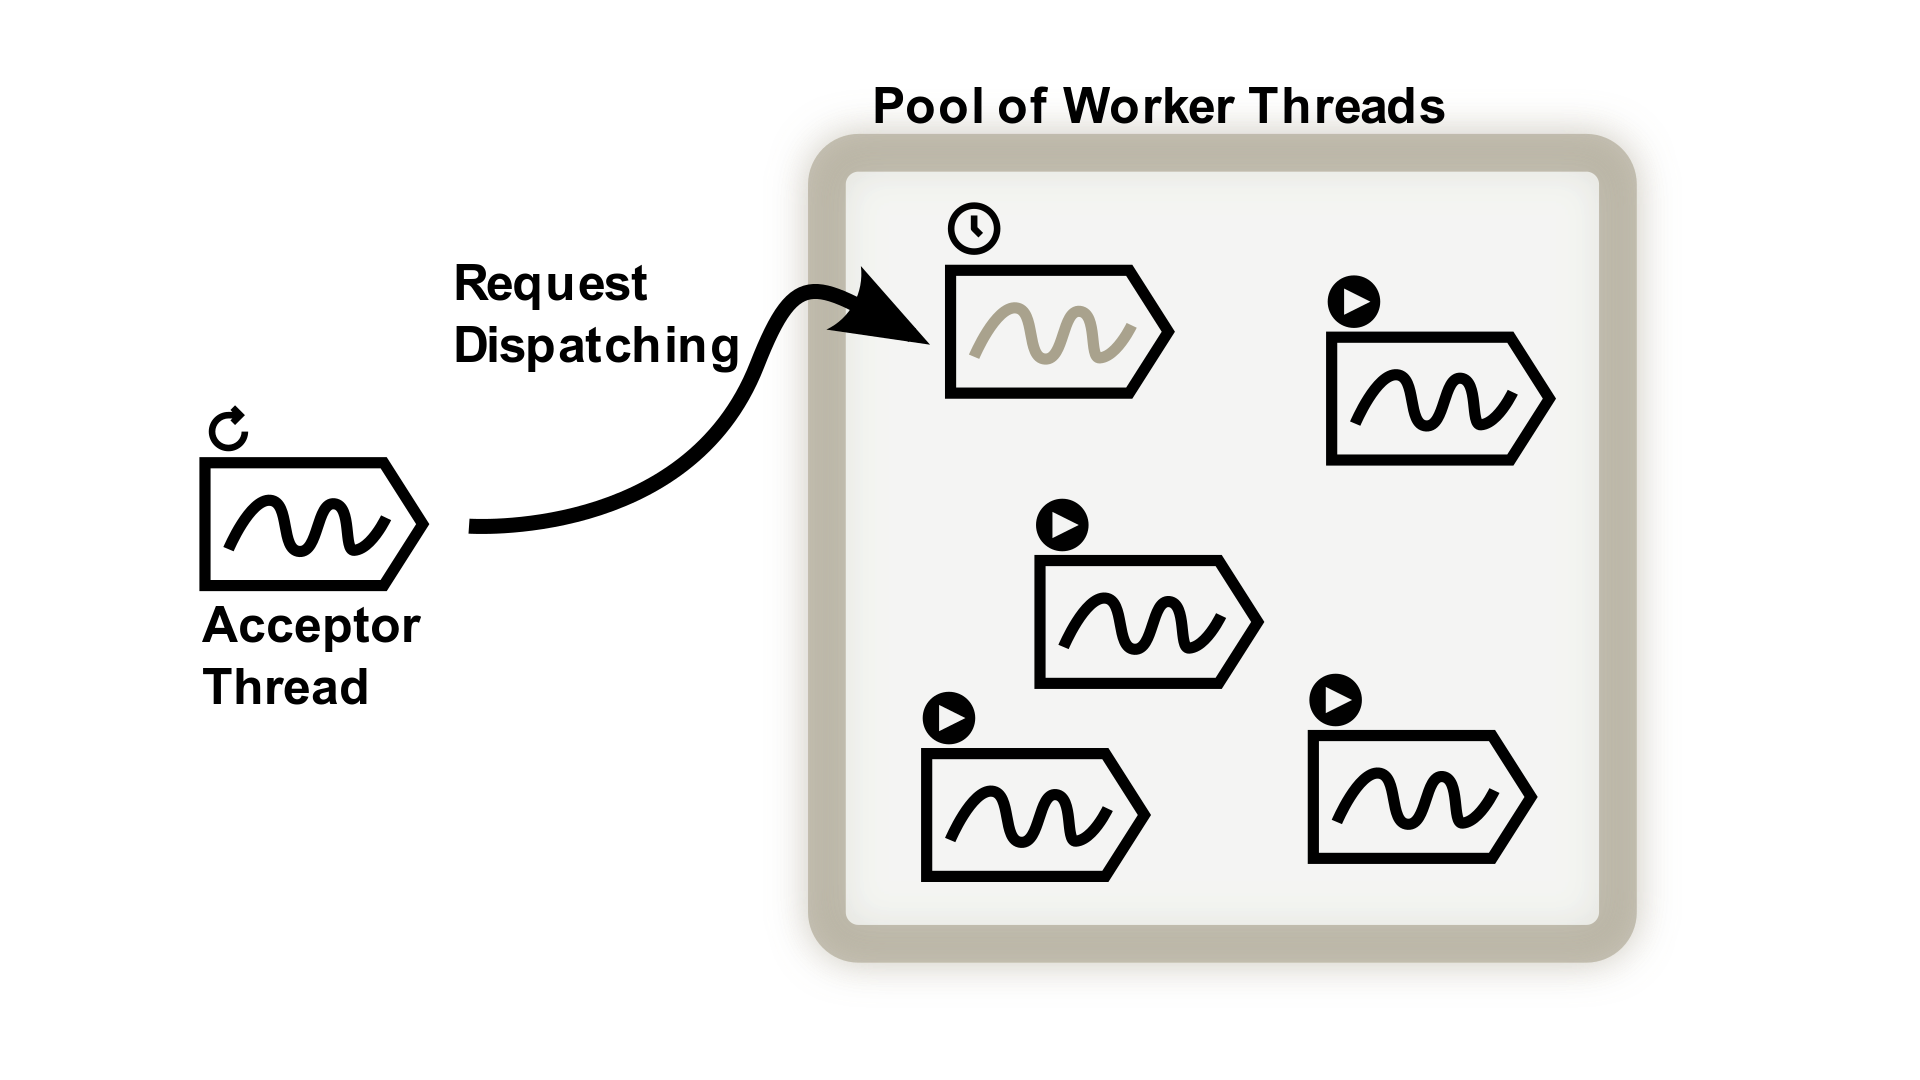

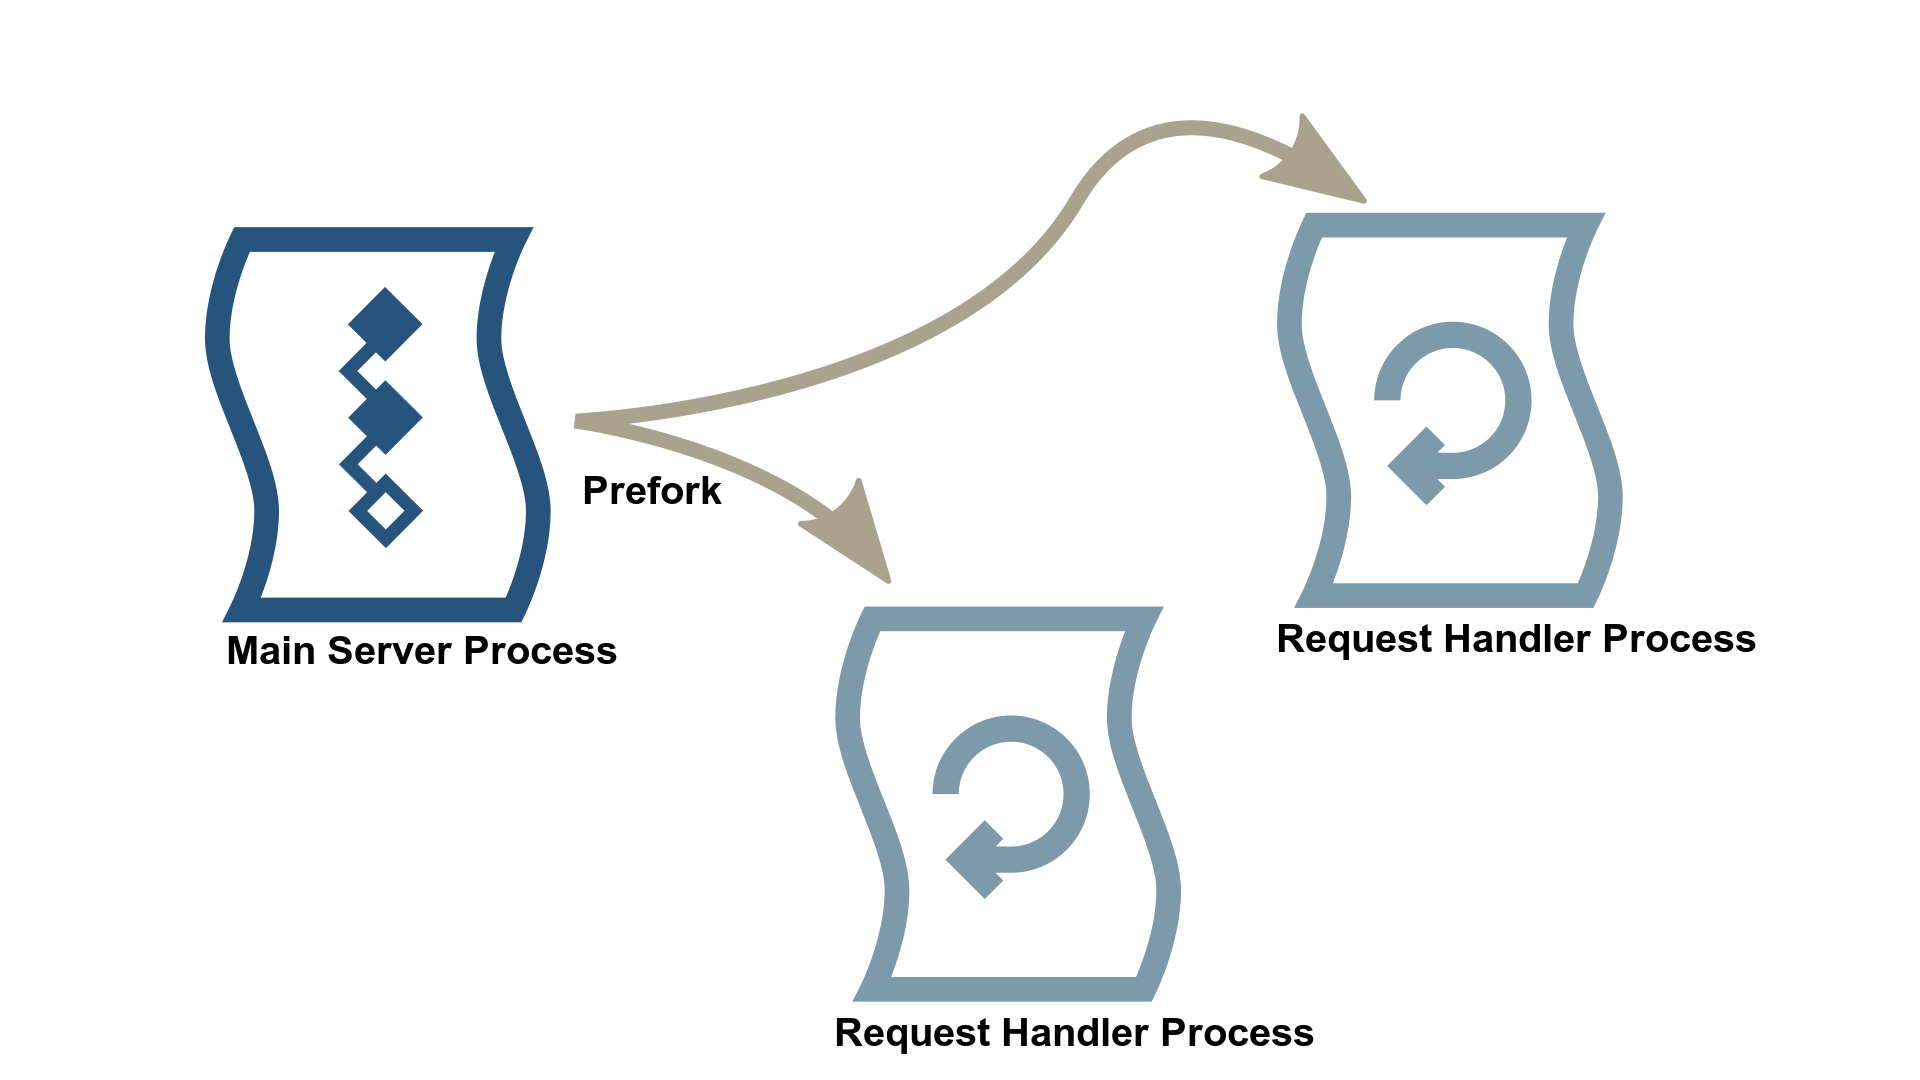

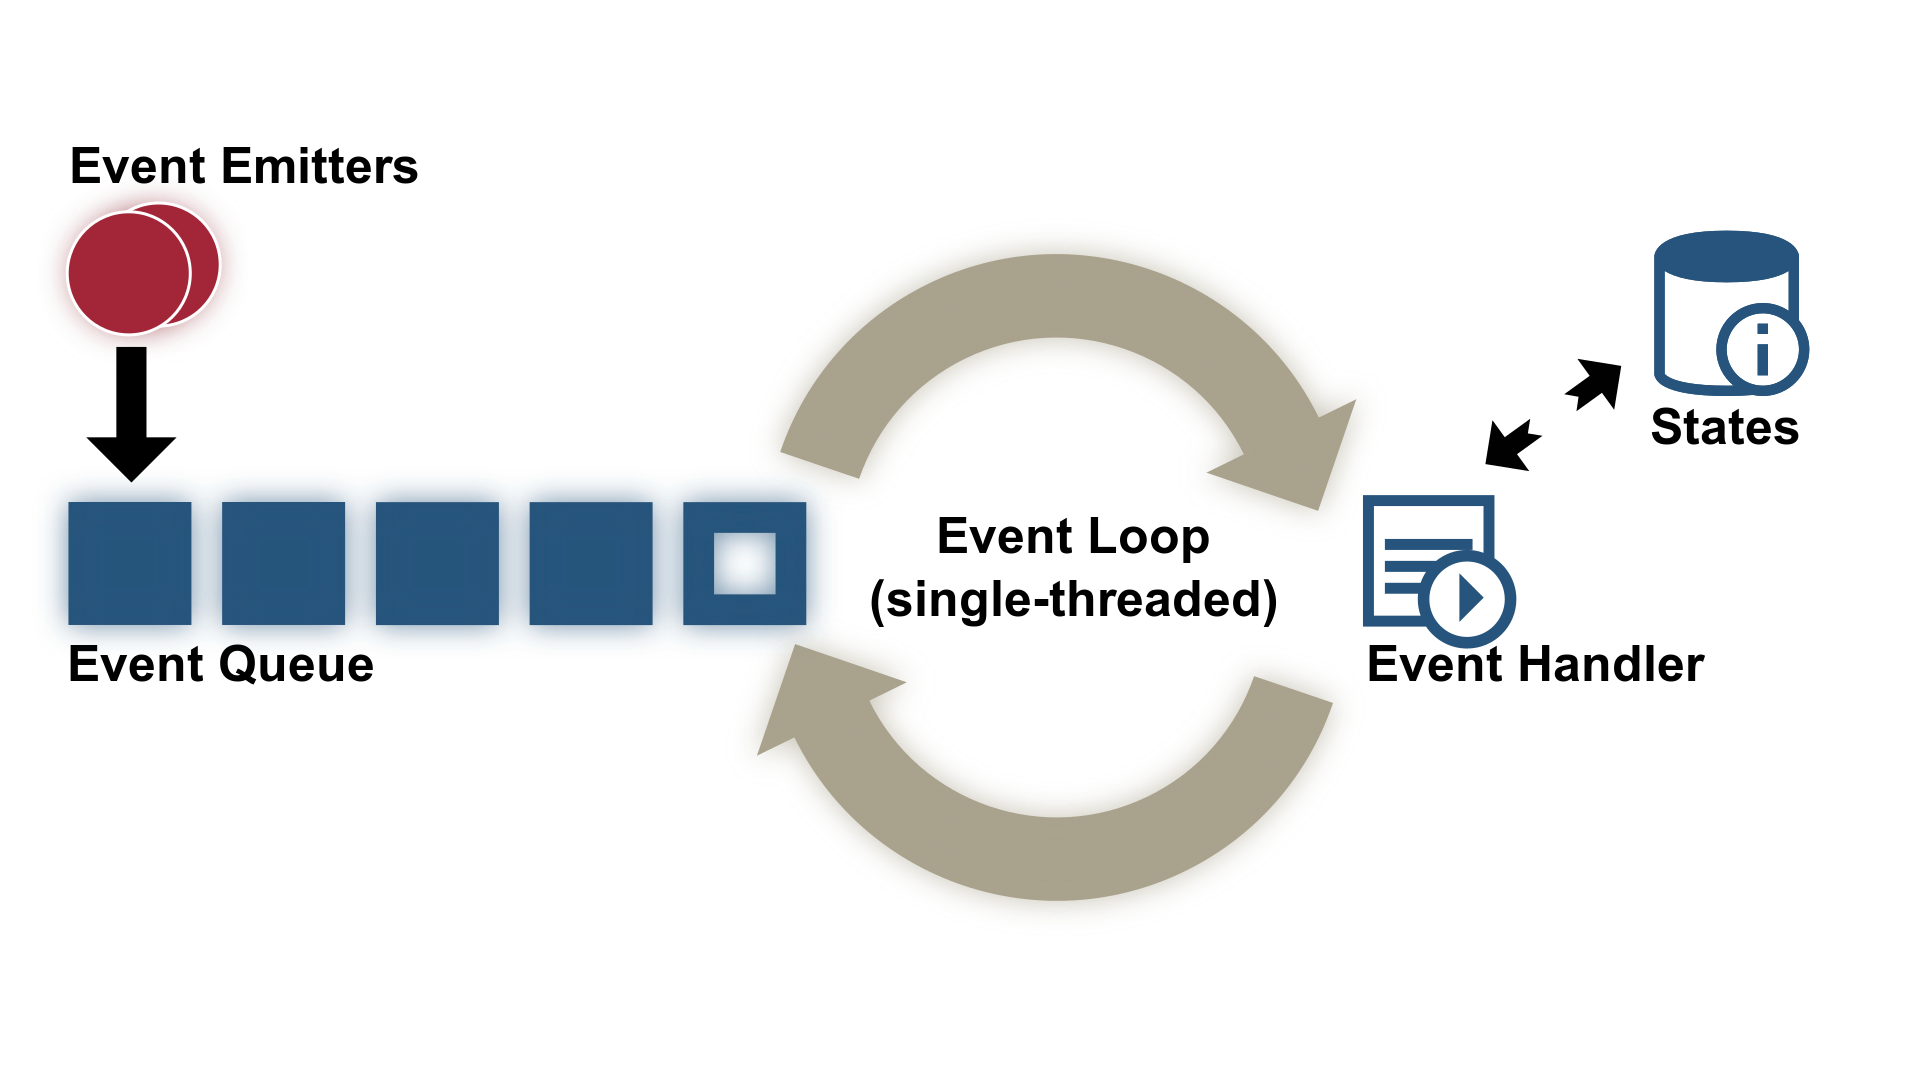

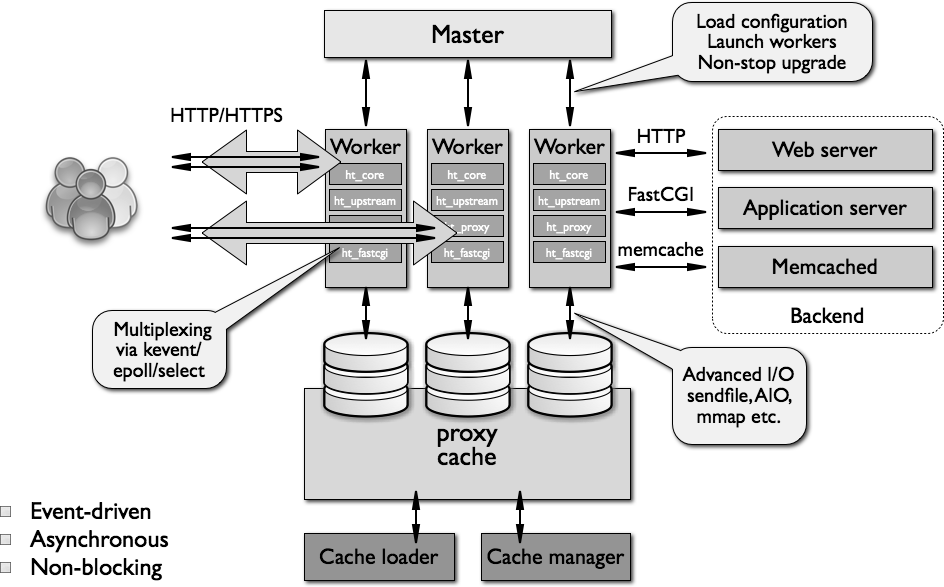

### References

* https://amarchenko.dev/translate/2023-10-02-network/
* http://www.apress.com/us/book/9781430230038
* http://www.dabeaz.com/python/PythonNetBinder.pdf
* http://www.tenouk.com/Module39a.html
* https://docs.python.org/2.7/howto/sockets.html
* https://hpbn.co/
* http://berb.github.io/diploma-thesis/original/042_serverarch.html
* https://www.ulduzsoft.com/2014/01/select-poll-epoll-practical-difference-for-system-architects/
* http://www.aosabook.org/en/nginx.html
* https://www.nginx.com/blog/inside-nginx-how-we-designed-for-performance-scale/
* https://www.youtube.com/watch?v=aE0yawwB6h4
* http://www.kegel.com/c10k.html
* https://www.slideshare.net/joshzhu/nginx-internals

### Summary

* sockets are almost file-like, but it's get tricky fast
* TCP is reliable stream-oriented protocol
* UDP is unrealiable packet-oriented protocol. Faster than TCP though
* Always use timeouts and retries
* requests is handy but devil in the details